# Demo 04: Fine-tune EpiZoo for cell type annotation

This notebook demonstrates how to fine-tune **EpiZoo** and get **EpiZooAnno** for cell type annotation task.

Starting from a pretrained EpiZoo model, users can fine-tune the model to their own scATAC-seq data. After fine-tuning, EpiZooAnno can be used to annotate cell types.

## Required files

Before running this notebook, please prepare the following files:

- **`model.pth`**: The pretrained EpiZoo model checkpoint. (The pretrained EpiZoo checkpoint can be downloaded at [pretrained_EpiZoo.pth](https://drive.google.com/file/d/1Xs5R_LAMbB_Zqpg7SFHlrAMfVcdcGwVE/view?usp=drive_link))

## Output

This notebook will generate:

- A fine-tuned EpiZooAnno model checkpoint
- Cell labels predicted by the fine-tuned model
- Metrics of the cell type annotation task
- Heatmap visualization

In [1]:
import os
import sys

# Add EpiZoo root directory
PROJECT_ROOT = os.path.abspath("../")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Step 1: Data processing

To prepare dataset for EpiZoo, we perform the following preprocessing steps:

1. **TF-IDF transformation:** Convert the raw count matrix into TF-IDF normalized values, which quantify the relative importance of accessible cCREs within each cell.

2. **Cell sentence generation:** Rank accessible cCREs according to their TF-IDF scores and convert each cell into a compact cell sentence composed of cCRE indices, which serves as the input for EpiZoo.

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd

from epizoo.data.processing import compute_tfidf, filter_cCREs, generate_cell_sentences

# 1. Load required data files
# Load the dataset
adata_file_path = "../data/Fang2021_downsampled_2000_cells.h5ad"
adata = sc.read_h5ad(adata_file_path)
print(f"Anndata: {adata}")

# Load the cCRE document frequency data (for mouse here)
df_file_path = "../data/cCRE_frequencies_mouse.npy"
df = np.load(df_file_path)
print(f"Document Frequency: {df}")

# Load the cCRE filter index (for mouse here)
filter_index_file_path = "../data/cCRE_filter_idx_mouse.csv"
filter_index = pd.read_csv(filter_index_file_path,index_col=0)['idx'].values
print(f"Filter Index: {filter_index}")

# 2. Preprocess the data
# Perform TF-IDF transformation
adata = compute_tfidf(adata, df, cell_number=12500000)

# Filter cCRE
adata = filter_cCREs(adata, filter_idx=filter_index, species=1)

# Generate cell sentences
adata = generate_cell_sentences(adata, species=1, species_offset=700460)
print(f"Cell Sentences:\n{adata.obs['cell_indices'][:5]}")

/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Anndata: AnnData object with n_obs × n_vars = 2000 × 1341077
    obs: 'prefix_barcode', 'sample name', 'barcode', 'tsne1', 'tsne2', 'celltype', 'celltype2', 'batch', 'dataset'
Document Frequency: [ 9086. 20040. 10906. ...  1046.  1051.  3763.]
Filter Index: [      3       4       8 ... 1341044 1341059 1341062]
TF-IDF completed. TF-IDF matrix stored in adata.X
Matrix shape: (2000, 1341077)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Data type: float32
Non-zero entries: 6,703,562
Sparsity: 99.7501%
Non-zero value min: 0.470534
Non-zero value max: 329.738953
Non-zero value mean: 12.603610
Non-zero value median: 8.776130
--------------------------------------------------
Accessible cCREs per cell:
  Mean: 3351.78
  Median: 2422.00
  Min: 494
  Max: 24220
Filtered cCREs: 814020 features retained.
Cell Sentences:
Fang2021_GSM3611838_CEMBA180305_2B_AGAGCAGTTTCCATCCTGCTGGTATTACGACC    [979641, 1263399, 1336016, 1012267, 1181117, 1...
Fang2021_GSM3611841_CEMBA180312_3B_GCTCTAAGCTAATGCTC

In [3]:
from sklearn.preprocessing import LabelEncoder

# Build label mapping
label_encoder = LabelEncoder()

adata.obs["cell_type_id"] = label_encoder.fit_transform(adata.obs["celltype"])
label_mapping = {
    cell_type: int(idx)
    for idx, cell_type in enumerate(label_encoder.classes_)
}

print(label_mapping)

{'Asc': 0, 'CGE': 1, 'End': 2, 'L23.a': 3, 'L23.b': 4, 'L23.c': 5, 'L4': 6, 'L5.IT.a': 7, 'L5.IT.b': 8, 'L5.PT': 9, 'L6.CT': 10, 'L6.IT': 11, 'Mgc': 12, 'NP': 13, 'Ogc': 14, 'Opc': 15, 'Other': 16, 'Pv': 17, 'Smc': 18, 'Sst': 19}


## Step 2: Create Dataset and DataLoader

After generating cell sentences, we construct `CellDatasetAnno` and DataLoader for model fine-tuning. Each cell is represented as a sequence of tokens with special tokens [CLS] and [SEP].

In [4]:
from epizoo.data.datasets import CellDatasetAnno, collate_fn_anno
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Split cells into train and test sets
train_idx, test_idx = train_test_split(np.arange(adata.n_obs), test_size=0.2, random_state=42, shuffle=True)
adata_train = adata[train_idx].copy()
adata_test = adata[test_idx].copy()

# Create a dataset and dataloader for training
train_dataset = CellDatasetAnno(
    cell_sentences=adata_train.obs['cell_indices'].values,
    labels=adata_train.obs['cell_type_id'].values,
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn_anno,
)

# Create a dataset and dataloader for testing
test_dataset = CellDatasetAnno(
    cell_sentences=adata_test.obs['cell_indices'].values,
    labels=adata_test.obs['cell_type_id'].values,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn_anno,
)

print(f"Training cells: {len(train_dataset)}, Testing cells: {len(test_dataset)}")

Training cells: 1600, Testing cells: 400


## Step 3: Load the pretrained EpiZoo model

We load the pretrained model checkpoint for fine-tuning.

In [5]:
import torch
from epizoo.models.epizoo_anno import EpiZooAnnoConfig, EpiZooAnno

# Load pretrained model
model_path = "/data/lizhen/epizoo/models/pretrained_EpiZoo.pth"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize EpiZoo model
config = EpiZooAnnoConfig(
    vocab_size = 700460 + 814020 + 4,
    num_layers = 30,
    num_classes = len(adata.obs['celltype'].unique()),
)
model = EpiZooAnno(cfg=config)

# Load pretrained weights
state_dict = torch.load(model_path, map_location="cpu")
msg = model.load_state_dict(state_dict, strict=False)

print("=" * 80)
print("Missing keys (new in EpiZooAnno):")
if len(msg.missing_keys) == 0:
    print("None")
else:
    for k in msg.missing_keys:
        print(f"  {k}")
print("Unexpected keys (not used in EpiZooAnno):")
if len(msg.unexpected_keys) == 0:
    print("None")
else:
    for k in msg.unexpected_keys:
        print(f"  {k}")
print("=" * 80)
print(f"Total missing keys: {len(msg.missing_keys)}")
print(f"Total unexpected keys: {len(msg.unexpected_keys)}")

# Move model to device
model = model.to(device)

print("EpiZooAnno model loaded successfully.")

Missing keys (new in EpiZooAnno):
  classifier.fc1.weight
  classifier.fc1.bias
  classifier.norm1.weight
  classifier.norm1.bias
  classifier.fc2.weight
  classifier.fc2.bias
  classifier.norm2.weight
  classifier.norm2.bias
  classifier.fc3.weight
  classifier.fc3.bias
Unexpected keys (not used in EpiZooAnno):
  cca_head.net.0.weight
  cca_head.net.0.bias
  cca_head.net.2.weight
  cca_head.net.2.bias
  cca_head.net.4.weight
  cca_head.net.4.bias
  signal_decoder.decoders.human.weight
  signal_decoder.decoders.human.bias
  signal_decoder.decoders.mouse.weight
  signal_decoder.decoders.mouse.bias
Total missing keys: 10
Total unexpected keys: 10
EpiZooAnno model loaded successfully.


## Step 4: Model training

We fine-tune the EpiZooAnno model for annotating cell types using `EpiZooAnnotationTrainer`.

The fine-tuned model checkpoint will be saved for downstream inference.

In [6]:
from epizoo.train.annotation import EpiZooAnnotationTrainer, AnnotationTrainConfig

# Fine-tuning configuration
ft_cfg = AnnotationTrainConfig(
    output_dir="/data/lizhen/epizoo/models/finetuned_model_anno",
    max_steps=1000,
    save_steps=200,
    log_steps=100,
    eval_steps=500,
    keep_last=2,
    lr=5e-5,
    warmup_steps=100,
    device=device,
)

trainer = EpiZooAnnotationTrainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=test_dataloader,
    cfg=ft_cfg,
)

# Start fine-tuning
finetuned_model = trainer.train()

Frozen seq_emb.


/home/jiangqun/miniconda3/envs/cellemu/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Step 100 | lr=5.000e-05 | loss=2.2844 | acc=0.3525 | kappa=0.3014 | macro_f1=0.2119
Step 200 | lr=5.000e-05 | loss=1.3384 | acc=0.7450 | kappa=0.7249 | macro_f1=0.6758
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_anno/202607150203_200.pth
Step 300 | lr=5.000e-05 | loss=0.9384 | acc=0.8450 | kappa=0.8344 | macro_f1=0.7880
Step 400 | lr=4.500e-05 | loss=0.7417 | acc=0.8825 | kappa=0.8735 | macro_f1=0.8748
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_anno/202607150205_400.pth
Epoch 1 finished. Time: 257.45s
Step 500 | lr=4.500e-05 | loss=0.5469 | acc=0.9250 | kappa=0.9196 | macro_f1=0.9355
Eval step 500 | val_loss=0.4758 | acc=0.8825 | kappa=0.8742 | macro_f1=0.8959
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_anno/best_model.pth
New best model saved. val_loss=0.4758
Step 600 | lr=4.500e-05 | loss=0.4554 | acc=0.9125 | kappa=0.9058 | macro_f1=0.9319
Checkpoint saved to /data/lizhen/epizoo/models/finetuned_model_anno/202607150208_600.pt

## Step 5: Predict cell types using the fine-tuned model

We use the `predict_cell_types` function to predict cell types using the fine-tuned model.

In [7]:
from epizoo.inference.annotation import predict_cell_types
from epizoo.metrics.classification import compute_classification_metrics

# Predict cell types
predicted_id = predict_cell_types(
    finetuned_model,
    test_dataloader,
    device=device,
    return_cell_emb=False,
)['predicted_labels']
print(f"Completed.")

# Map predicted label indices back to cell type names
id_to_label = {
    idx: cell_type
    for cell_type, idx in label_mapping.items()
}
predicted_celltypes = np.array([
    id_to_label[i]
    for i in predicted_id
])

# Compute metrics
acc, kappa, macro_f1 = compute_classification_metrics(
    labels=adata_test.obs['celltype'].values,
    preds=predicted_celltypes,
).values()
print(f"Accuracy: {acc:.4f}, Cohen's Kappa: {kappa:.4f}, Macro F1 Score: {macro_f1:.4f}")

Predicting cell types: 100%|██████████| 13/13 [00:07<00:00,  1.75it/s]

Completed.
Accuracy: 0.9125, Cohen's Kappa: 0.9064, Macro F1 Score: 0.9242


## Step 6: Heatmap visualization

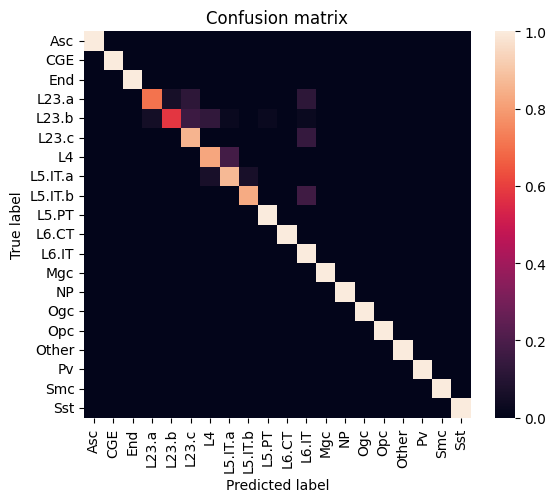

<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

In [8]:
from epizoo.visualization.heatmap import plot_confusion_heatmap

plot_confusion_heatmap(
    labels=adata_test.obs['cell_type_id'].values,
    preds=predicted_id,
    class_names=list(label_mapping.keys()),
    show=True,
    figsize=(6,5),
)